# Sales Data Analysis — 2019

Phân tích 186.850 giao dịch bán lẻ sản phẩm điện tử trong năm 2019, gộp từ 12 file CSV theo tháng.

**Mục tiêu:** làm sạch dữ liệu và trả lời 5 câu hỏi nghiệp vụ:

1. Tháng nào bán tốt nhất và doanh thu bao nhiêu?
2. Thành phố nào có doanh thu cao nhất?
3. Nên chạy quảng cáo vào khung giờ nào?
4. Những sản phẩm nào thường được mua cùng nhau?
5. Sản phẩm nào bán chạy nhất và vì sao?

**Tech stack:** Python 3 · pandas · matplotlib

---
## Task 1 — Import packages and load data

In [1]:
import glob
import re
from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True

Dữ liệu nằm trong thư mục `Data/`. Notebook dùng đường dẫn tương đối, nên hãy mở Jupyter ngay tại
thư mục chứa project.

Pattern glob là `sales2019_[0-9]*.csv` — cố ý **không** dùng `sales2019_*.csv` vì pattern đó sẽ khớp
luôn file kết quả `sales2019_all.csv`, làm dữ liệu bị nhân đôi mỗi lần chạy lại.

In [2]:
DATA_DIR = "Data"
MERGED_FILE = f"{DATA_DIR}/sales2019_all.csv"

# Chỉ lấy 12 file theo tháng, bỏ qua file tổng hợp sales2019_all.csv
all_files = glob.glob(f"{DATA_DIR}/sales2019_[0-9]*.csv")


def extract_month(filename):
    """Lấy số tháng từ tên file, ví dụ 'Data/sales2019_10.csv' -> 10."""
    match = re.search(r"_(\d+)\.csv$", filename)
    return int(match.group(1)) if match else 0


all_files = sorted(all_files, key=extract_month)

print(f"Tìm thấy {len(all_files)} file:")
for f in all_files:
    print(" ", f)

Tìm thấy 12 file:
  Data/sales2019_1.csv
  Data/sales2019_2.csv
  Data/sales2019_3.csv
  Data/sales2019_4.csv
  Data/sales2019_5.csv
  Data/sales2019_6.csv
  Data/sales2019_7.csv
  Data/sales2019_8.csv
  Data/sales2019_9.csv
  Data/sales2019_10.csv
  Data/sales2019_11.csv
  Data/sales2019_12.csv


In [3]:
# Đọc và gộp
df_list = [pd.read_csv(f) for f in all_files]
merged_df = pd.concat(df_list, ignore_index=True)

print("Kích thước sau khi gộp:", merged_df.shape)

Kích thước sau khi gộp: (186850, 6)


In [4]:
# Xuất file tổng hợp
merged_df.to_csv(MERGED_FILE, index=False)

In [5]:
df = pd.read_csv(MERGED_FILE)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


---
## Task 2 — Clean and preprocess data

### 2.1 Xác định dữ liệu rác

Vì 12 file được nối lại với nhau, dòng tiêu đề của các file sau bị lẫn vào giữa dữ liệu.
Ngoài ra còn có những dòng trống hoàn toàn.

In [6]:
blank_rows = df.isna().all(axis=1).sum()
header_rows = (df["Order ID"] == "Order ID").sum()

print(f"Dòng trống hoàn toàn : {blank_rows}")
print(f"Dòng tiêu đề lặp     : {header_rows}")
print(f"Tổng cần loại bỏ     : {blank_rows + header_rows}")

Dòng trống hoàn toàn : 545
Dòng tiêu đề lặp     : 355
Tổng cần loại bỏ     : 900


In [7]:
rows_before = len(df)

df = df.dropna(how="all")                    # bỏ dòng trống
df = df[df["Order ID"] != "Order ID"]        # bỏ dòng tiêu đề lặp
df = df.reset_index(drop=True)

print(f"{rows_before:,} -> {len(df):,} dòng  (đã loại {rows_before - len(df):,})")

186,850 -> 185,950 dòng  (đã loại 900)


### 2.2 Ép kiểu dữ liệu

Vì file gốc lẫn dòng tiêu đề nên pandas đọc mọi cột thành `object`. Cần chuyển về kiểu số và datetime.

Lưu ý: giữ `Price Each` ở **float64**. Nếu downcast xuống `float32` thì chỉ còn ~7 chữ số có nghĩa,
trong khi doanh thu cộng dồn lên tới 8 chữ số — giá 149.99 sẽ bị lưu thành 149.990005 và tổng bị lệch.

In [8]:
df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"])
df["Price Each"] = pd.to_numeric(df["Price Each"])
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%y %H:%M")

df.dtypes

Order ID                    object
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object

### 2.3 Tạo các cột phái sinh

- `Month`, `Hour` — tách từ `Order Date`
- `Sales` = `Quantity Ordered` × `Price Each`
- `City` — tách từ `Purchase Address`, **kèm mã bang**

Về `City`: dataset có **hai thành phố tên Portland** (Portland OR và Portland ME). Nếu chỉ lấy tên
thành phố thì doanh thu của hai nơi này bị cộng gộp làm một. Vì vậy phải ghép thêm bang để phân biệt.

In [9]:
df["Month"] = df["Order Date"].dt.month
df["Hour"] = df["Order Date"].dt.hour
df["Sales"] = df["Quantity Ordered"] * df["Price Each"]


def extract_city(address):
    """'538 Adams St, San Francisco, CA 94016' -> 'San Francisco (CA)'"""
    parts = address.split(",")
    city = parts[1].strip()
    state = parts[2].strip().split(" ")[0]
    return f"{city} ({state})"


df["City"] = df["Purchase Address"].apply(extract_city)

# Đưa cột Sales lên ngay sau Price Each cho dễ đọc
df.insert(4, "Sales", df.pop("Sales"))

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Sales,Order Date,Purchase Address,Month,Hour,City
0,141234,iPhone,1,700.00,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",1,21,Boston (MA)
1,141235,Lightning Charging Cable,1,14.95,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",1,14,Portland (OR)
2,141236,Wired Headphones,2,11.99,23.98,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",1,13,San Francisco (CA)
3,141237,27in FHD Monitor,1,149.99,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",1,20,Los Angeles (CA)
4,141238,Wired Headphones,1,11.99,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",1,11,Austin (TX)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  object        
 1   Product           185950 non-null  object        
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Sales             185950 non-null  float64       
 5   Order Date        185950 non-null  datetime64[ns]
 6   Purchase Address  185950 non-null  object        
 7   Month             185950 non-null  int32         
 8   Hour              185950 non-null  int32         
 9   City              185950 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(4)
memory usage: 12.8+ MB


Dữ liệu đã sạch: **185.950 dòng**, không còn giá trị thiếu, kiểu dữ liệu đúng.

---
## Task 3 — Report

### 3.1 — Tháng nào bán tốt nhất? Doanh thu bao nhiêu?

In [11]:
sales_by_month = df.groupby("Month")["Sales"].sum()
sales_by_month.round(2)

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

In [12]:
best_month = sales_by_month.idxmax()

print(f"Tổng doanh thu 2019 : ${df['Sales'].sum():,.2f}")
print(f"Tháng tốt nhất      : tháng {best_month} — ${sales_by_month.max():,.2f}")
print(f"Tháng thấp nhất     : tháng {sales_by_month.idxmin()} — ${sales_by_month.min():,.2f}")

Tổng doanh thu 2019 : $34,492,035.97
Tháng tốt nhất      : tháng 12 — $4,613,443.34
Tháng thấp nhất     : tháng 1 — $1,822,256.73


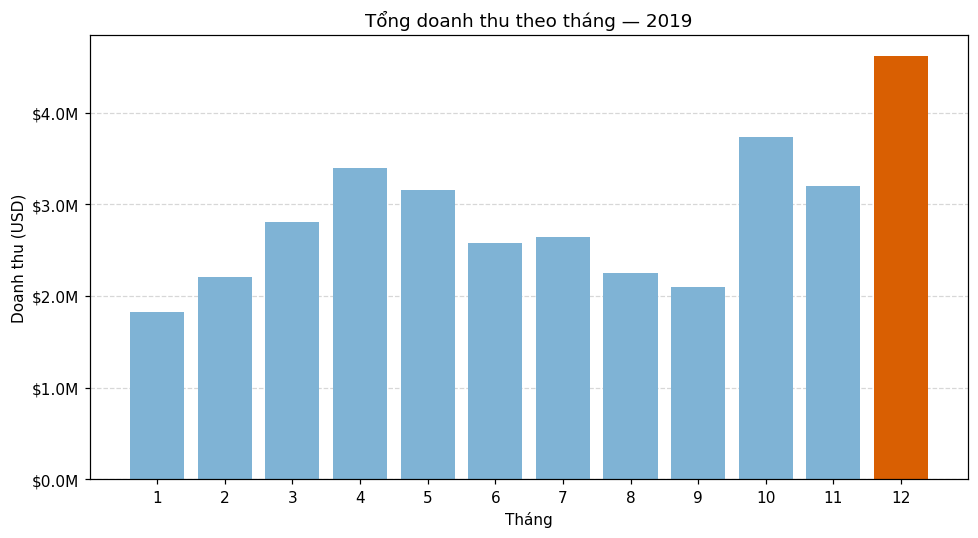

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#d95f02" if m == best_month else "#7fb3d5" for m in sales_by_month.index]
ax.bar(sales_by_month.index, sales_by_month.values, color=colors)

ax.set_xticks(range(1, 13))
ax.set_xlabel("Tháng")
ax.set_ylabel("Doanh thu (USD)")
ax.set_title("Tổng doanh thu theo tháng — 2019")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.show()

**Nhận xét:** Tháng 12 dẫn đầu rõ rệt nhờ mùa mua sắm cuối năm, gấp hơn 2,5 lần tháng 1 — tháng thấp
nhất. Có hai đỉnh phụ vào tháng 4 và tháng 10. Đầu năm (tháng 1–3) là giai đoạn trầm nhất,
nhiều khả năng do hiệu ứng "hụt hơi" ngay sau mùa lễ.

### 3.2 — Thành phố nào có doanh thu cao nhất?

In [14]:
sales_by_city = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
sales_by_city.round(2)

City
San Francisco (CA)    8262203.91
Los Angeles (CA)      5452570.80
New York City (NY)    4664317.43
Boston (MA)           3661642.01
Atlanta (GA)          2795498.58
Dallas (TX)           2767975.40
Seattle (WA)          2747755.48
Portland (OR)         1870732.34
Austin (TX)           1819581.75
Portland (ME)          449758.27
Name: Sales, dtype: float64

In [15]:
print(f"Thành phố dẫn đầu: {sales_by_city.idxmax()} — ${sales_by_city.max():,.2f}")
print(f"Chiếm {sales_by_city.max() / df['Sales'].sum():.1%} tổng doanh thu")

Thành phố dẫn đầu: San Francisco (CA) — $8,262,203.91
Chiếm 24.0% tổng doanh thu


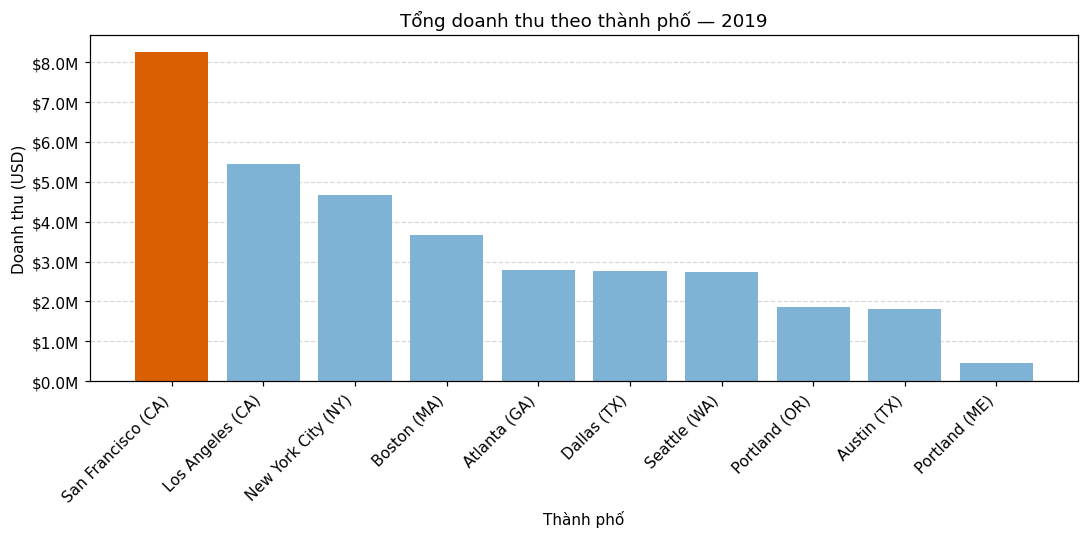

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#d95f02"] + ["#7fb3d5"] * (len(sales_by_city) - 1)
ax.bar(sales_by_city.index, sales_by_city.values, color=colors)

ax.set_xlabel("Thành phố")
ax.set_ylabel("Doanh thu (USD)")
ax.set_title("Tổng doanh thu theo thành phố — 2019")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.show()

**Nhận xét:** San Francisco áp đảo với gần 24% tổng doanh thu — cao hơn Los Angeles (hạng 2) khoảng
50%. Ba thành phố dẫn đầu đều là trung tâm công nghệ / tài chính lớn, phù hợp với mặt hàng điện tử.

Việc tách theo bang cho thấy Portland (OR) và Portland (ME) là hai thị trường hoàn toàn khác nhau về
quy mô — nếu gộp chung sẽ đánh giá sai tiềm năng của cả hai.

### 3.3 — Nên chạy quảng cáo vào khung giờ nào?

In [17]:
orders_by_hour = df.groupby("Hour")["Order ID"].count()
sales_by_hour = df.groupby("Hour")["Sales"].sum()

peak_hours = orders_by_hour.sort_values(ascending=False).head(5)
print("Top 5 khung giờ theo số đơn:")
for hour, n in peak_hours.items():
    print(f"  {hour:02d}:00 — {n:,} đơn")

Top 5 khung giờ theo số đơn:
  19:00 — 12,905 đơn
  12:00 — 12,587 đơn
  11:00 — 12,411 đơn
  18:00 — 12,280 đơn
  20:00 — 12,228 đơn


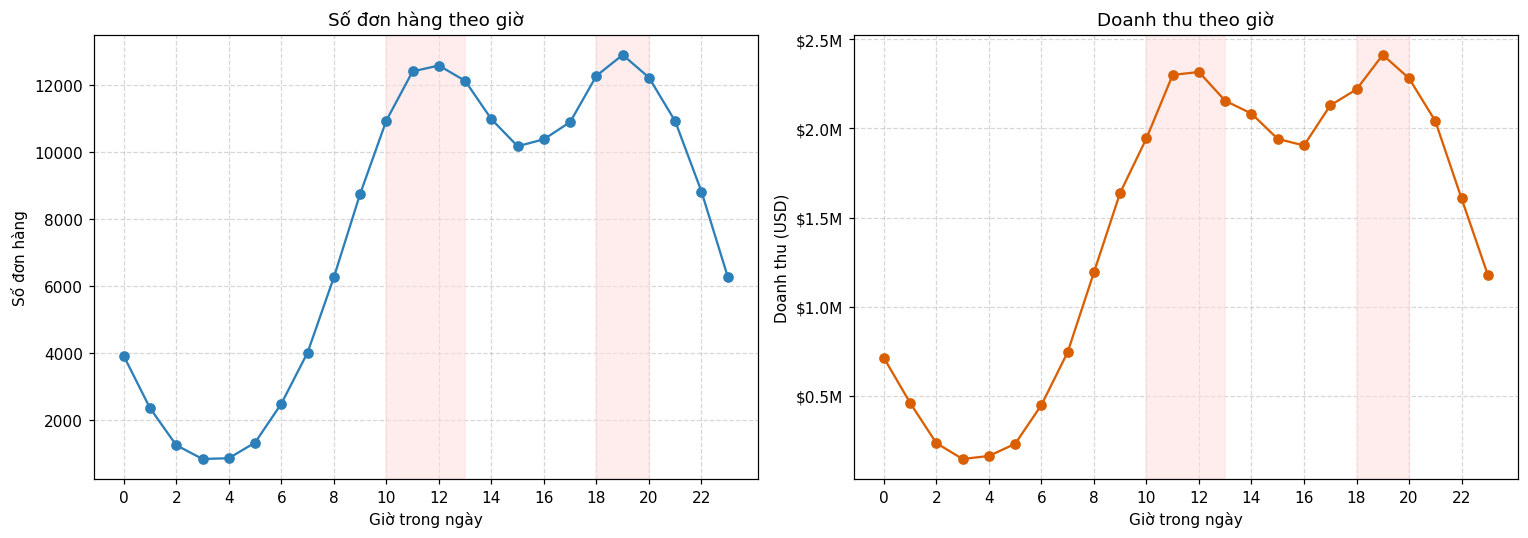

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(orders_by_hour.index, orders_by_hour.values, marker="o", color="#2c7fb8")
ax1.set_title("Số đơn hàng theo giờ")
ax1.set_ylabel("Số đơn hàng")

ax2.plot(sales_by_hour.index, sales_by_hour.values, marker="o", color="#d95f02")
ax2.set_title("Doanh thu theo giờ")
ax2.set_ylabel("Doanh thu (USD)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

for ax in (ax1, ax2):
    ax.set_xlabel("Giờ trong ngày")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    # Tô đậm hai khung giờ cao điểm
    ax.axvspan(10, 13, color="#fdd", alpha=0.5)
    ax.axvspan(18, 20, color="#fdd", alpha=0.5)

plt.show()

**Nhận xét:** Biểu đồ có hình **hai bướu** rất rõ:

- Đỉnh trưa: **11:00 – 13:00**
- Đỉnh tối: **18:00 – 20:00**, trong đó **19:00 là giờ cao điểm nhất trong ngày**

Giữa hai đỉnh (15:00 – 16:00) lượng đơn chững lại khoảng 10.200 đơn/giờ, và **02:00 – 05:00 là đáy**
với chưa tới 1.400 đơn/giờ — riêng 03:00 chỉ có 831 đơn, thấp hơn giờ cao điểm 15 lần.

Biểu đồ doanh thu có hình dạng gần như trùng khớp với biểu đồ số đơn, nghĩa là giá trị đơn hàng
trung bình không thay đổi nhiều theo giờ — khung giờ ảnh hưởng đến **số lượng** người mua chứ không
phải đến việc họ mua đắt hay rẻ.

**Khuyến nghị:** đặt quảng cáo ngay **trước** giờ cao điểm — khoảng **10:00–11:00** và **18:00–19:00** —
để người dùng nhìn thấy quảng cáo đúng lúc họ chuẩn bị mua. Không nên chi ngân sách cho khung 02:00–06:00.

### 3.4 — Những sản phẩm nào thường được mua cùng nhau?

Các dòng có cùng `Order ID` là những sản phẩm nằm chung một đơn hàng. Gộp chúng lại rồi đếm tần suất
xuất hiện của từng **cặp** sản phẩm.

Trước khi tạo cặp cần `sorted(set(...))`: `set` để một sản phẩm mua 2 lần trong cùng đơn không ghép
với chính nó, `sorted` để chuẩn hoá thứ tự — nếu không thì `(iPhone, Cable)` và `(Cable, iPhone)`
bị đếm thành hai cặp khác nhau và tần suất thực tế bị chia nhỏ.

In [19]:
# Chỉ giữ các đơn có từ 2 sản phẩm trở lên
df_multi = df[df["Order ID"].duplicated(keep=False)].copy()
df_multi["Grouped"] = df_multi.groupby("Order ID")["Product"].transform(lambda x: ", ".join(x))

df_grouped = df_multi[["Order ID", "Grouped"]].drop_duplicates()

print(f"Số đơn có nhiều hơn 1 sản phẩm: {len(df_grouped):,} "
      f"({len(df_grouped) / df['Order ID'].nunique():.1%} tổng số đơn)")
df_grouped.head()

Số đơn có nhiều hơn 1 sản phẩm: 7,136 (4.0% tổng số đơn)


,Order ID,Grouped
41,141275,"USB-C Charging Cable, Wired Headphones"
57,141290,"Apple Airpods Headphones, AA Batteries (4-pack)"
133,141365,"Vareebadd Phone, Wired Headphones"
153,141384,"Google Phone, USB-C Charging Cable"
220,141450,"Google Phone, Bose SoundSport Headphones"


In [20]:
count = Counter()

for row in df_grouped["Grouped"]:
    products = [p.strip() for p in row.split(",")]
    count.update(combinations(sorted(set(products)), 2))

top_combos = pd.DataFrame(
    [(f"{a}  +  {b}", n) for (a, b), n in count.most_common(10)],
    columns=["Combo", "Frequency"],
)
top_combos

,Combo,Frequency
0,Lightning Charging Cable + iPhone,1011
1,Google Phone + USB-C Charging Cable,997
2,Wired Headphones + iPhone,462
3,Google Phone + Wired Headphones,422
4,Apple Airpods Headphones + iPhone,373
5,USB-C Charging Cable + Vareebadd Phone,368
6,Bose SoundSport Headphones + Google Phone,228
7,USB-C Charging Cable + Wired Headphones,203
8,Vareebadd Phone + Wired Headphones,149
9,Lightning Charging Cable + Wired Headphones,129


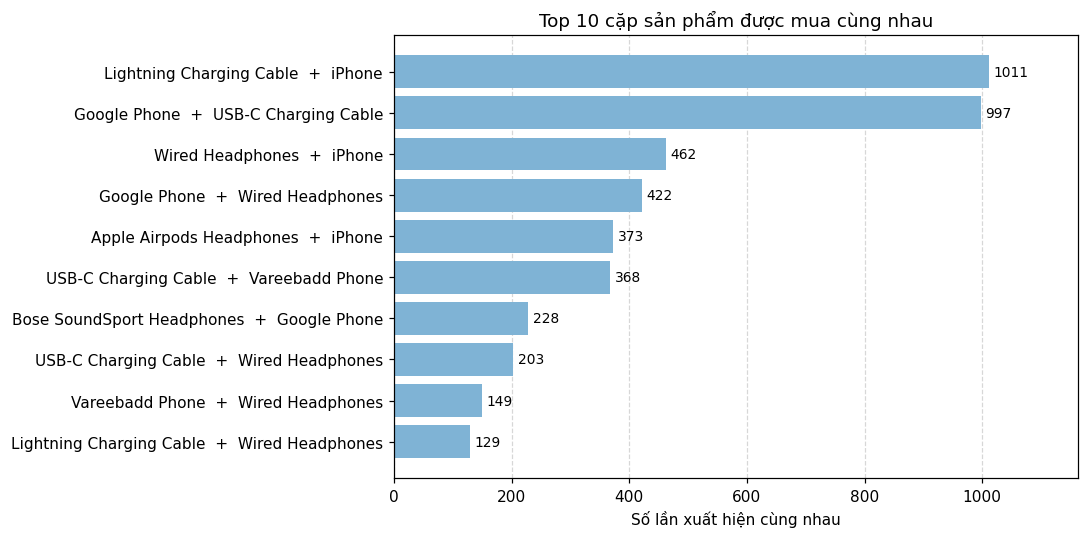

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top_combos["Combo"][::-1], top_combos["Frequency"][::-1], color="#7fb3d5")
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

ax.set_xlabel("Số lần xuất hiện cùng nhau")
ax.set_title("Top 10 cặp sản phẩm được mua cùng nhau")
ax.set_xlim(0, top_combos["Frequency"].max() * 1.15)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.show()

**Nhận xét:** Toàn bộ top 10 đều theo cùng một mô-típ — **điện thoại đi kèm phụ kiện tương thích**:

| Combo | Tần suất |
|---|---|
| iPhone + Lightning Charging Cable | 1.011 |
| Google Phone + USB-C Charging Cable | 997 |
| iPhone + Wired Headphones | 462 |

Đáng chú ý là cáp sạc luôn ghép đúng chuẩn của máy (Lightning cho iPhone, USB-C cho Google/Vareebadd) —
đây là hành vi mua kèm bắt buộc chứ không phải ngẫu nhiên.

**Khuyến nghị:** dựng gói bán kèm (bundle) và gợi ý "mua cùng" ngay tại trang sản phẩm điện thoại.

### 3.5 — Sản phẩm nào bán chạy nhất? Vì sao?

In [22]:
product_sales = df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)
product_prices = df.groupby("Product")["Price Each"].mean()[product_sales.index]

pd.DataFrame({
    "Quantity Ordered": product_sales,
    "Avg Price": product_prices.round(2),
    "Revenue": (df.groupby("Product")["Sales"].sum()[product_sales.index]).round(2),
})

,Quantity Ordered,Avg Price,Revenue
Product,,,
AAA Batteries (4-pack),31017,2.99,92740.83
AA Batteries (4-pack),27635,3.84,106118.40
USB-C Charging Cable,23975,11.95,286501.25
Lightning Charging Cable,23217,14.95,347094.15
Wired Headphones,20557,11.99,246478.43
Apple Airpods Headphones,15661,150.00,2349150.00
Bose SoundSport Headphones,13457,99.99,1345565.43
27in FHD Monitor,7550,149.99,1132424.50
iPhone,6849,700.00,4794300.00


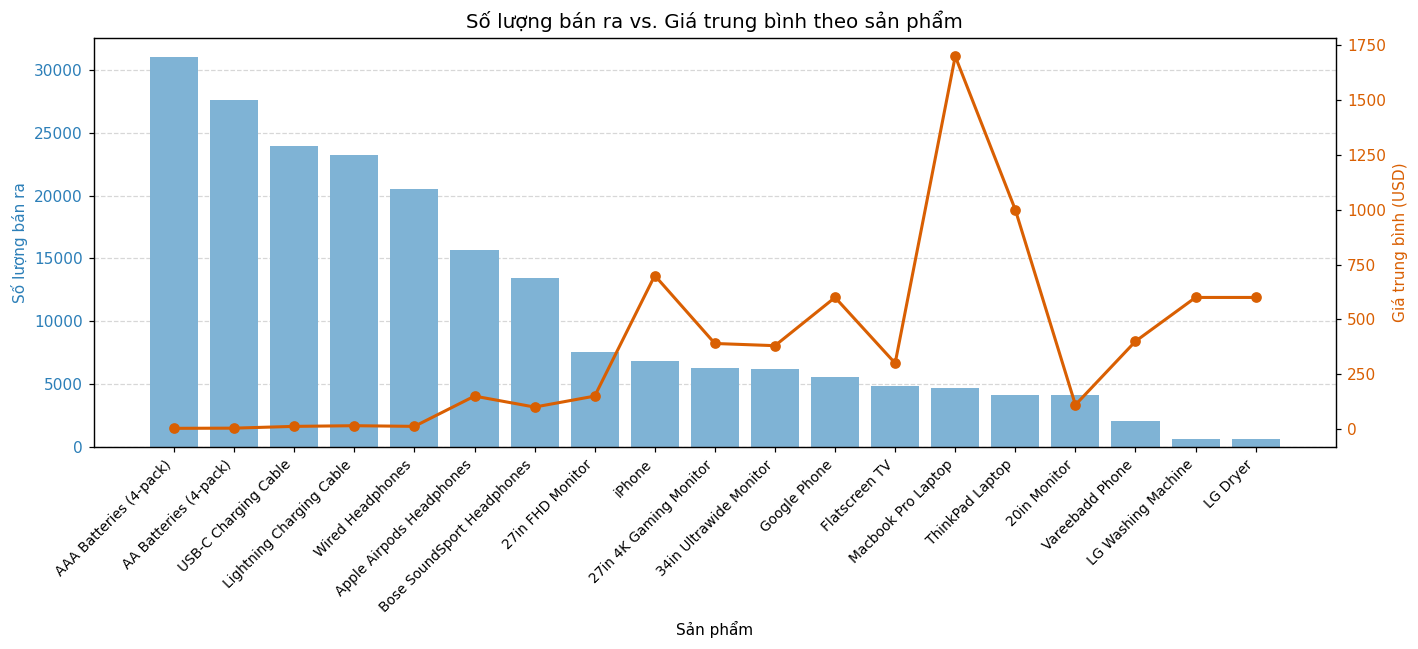

In [23]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(product_sales.index, product_sales.values, color="#7fb3d5", label="Quantity Ordered")
ax1.set_xlabel("Sản phẩm")
ax1.set_ylabel("Số lượng bán ra", color="#2c7fb8")
ax1.tick_params(axis="y", labelcolor="#2c7fb8")
ax1.tick_params(axis="x", rotation=45)
plt.setp(ax1.get_xticklabels(), ha="right", fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(product_prices.index, product_prices.values,
         color="#d95f02", marker="o", linewidth=2, label="Avg Price")
ax2.set_ylabel("Giá trung bình (USD)", color="#d95f02")
ax2.tick_params(axis="y", labelcolor="#d95f02")

ax1.set_title("Số lượng bán ra vs. Giá trung bình theo sản phẩm", fontsize=13)
plt.show()

In [24]:
corr = product_sales.corr(product_prices, method="spearman")
print(f"Tương quan hạng (Spearman) giữa giá và số lượng bán: {corr:.2f}")

Tương quan hạng (Spearman) giữa giá và số lượng bán: -0.78


**Nhận xét:** Hai biểu đồ gần như là ảnh phản chiếu của nhau — **giá càng thấp, số lượng bán càng cao**,
với hệ số tương quan hạng khoảng −0,78 (tương quan nghịch mạnh).

- Bán chạy nhất: **AAA Batteries (4-pack)** — 31.017 chiếc, giá chỉ $2,99
- Kế tiếp: AA Batteries ($3,84) và các loại cáp sạc (~$11–15)
- Bán ít nhất: LG Dryer và LG Washing Machine (~$600) — chỉ khoảng 650 chiếc

**Lý do:** pin và cáp sạc là hàng tiêu hao, giá rẻ, mua lặp lại nhiều lần và gần như không cần cân nhắc.
Ngược lại, máy giặt/máy sấy là khoản chi lớn, chu kỳ mua hàng nhiều năm một lần.

Lưu ý quan trọng: **bán chạy theo số lượng không đồng nghĩa với đóng góp doanh thu lớn**. Macbook Pro
Laptop chỉ bán 4.728 chiếc nhưng mang lại doanh thu cao nhất toàn danh mục ($8,04 triệu), trong khi
AAA Batteries bán nhiều gấp 6,5 lần nhưng lại **thấp nhất về doanh thu** (chỉ $92.741).

---
## Kết luận

| # | Câu hỏi | Trả lời |
|---|---|---|
| 1 | Tháng bán tốt nhất | **Tháng 12** — $4.613.443 (mùa lễ cuối năm) |
| 2 | Thành phố dẫn đầu | **San Francisco (CA)** — $8.262.204, ~24% tổng doanh thu |
| 3 | Giờ chạy quảng cáo | **10–11h** và **18–19h**, ngay trước hai đỉnh mua hàng |
| 4 | Combo phổ biến nhất | **iPhone + Lightning Charging Cable** (1.011 lần) |
| 5 | Sản phẩm bán chạy nhất | **AAA Batteries (4-pack)** — 31.017 chiếc, nhờ giá rẻ và là hàng tiêu hao |

**Tổng doanh thu 2019: $34.492.035,97** trên 185.950 giao dịch.

### Hướng phát triển tiếp

- Phân tích theo doanh thu thay vì số lượng để xác định sản phẩm chủ lực thực sự
- Tính giá trị đơn hàng trung bình (AOV) theo thành phố
- Áp dụng market basket analysis đầy đủ (support / confidence / lift) thay vì chỉ đếm tần suất cặp
- Xem xét yếu tố mùa vụ riêng cho từng nhóm sản phẩm